In [1]:
import demes
import scipy
import pickle
import demesdraw
import sparse

import numpy as np
import matplotlib.pyplot as plt

import sys

from momi3.Params import Params
from momi3.MOMI import Momi

from matplotlib.colors import LogNorm

import seaborn as sns

/home/enesdilber/momi3/src/momi3/utils.py:23: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
import jax
jax.devices()

[CpuDevice(id=0)]

# Complete Expected Site Frequency Spectrum

In [3]:
b = demes.Builder()
b.add_deme("AB", epochs = [dict(start_size = 10, end_time = 100)])
b.add_deme("A", ancestors = ["AB"], epochs = [dict(start_size = 80)])
b.add_deme("B", ancestors = ["AB"], epochs = [dict(start_size = 80)])
b.add_pulse(sources = ["A"], dest = "B", time = 50, proportions = [0.1])
g = b.resolve()

sampled_demes = ["A", "B"]
sample_sizes = [7, 7]
momi = Momi(g, sampled_demes=sampled_demes, sample_sizes=sample_sizes, low_memory=False)

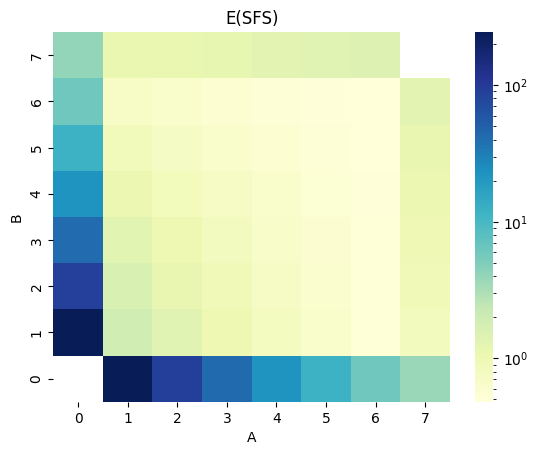

In [4]:
# Calculate the full spectrum
SFS = momi.sfs_spectrum()
sns.heatmap(SFS, cmap='YlGnBu', annot=False, norm=LogNorm())
plt.xlabel("A")
plt.ylabel("B")
plt.gca().invert_yaxis()
plt.title("E(SFS)");


# Partial Expected Site Frequency

When there are too many demes and too many samples, we might want to only calculate the allele frequency of most probable sites

In [7]:
b = demes.Builder()

b.add_deme("AB", epochs=[dict(start_size=10, end_time=100)])
b.add_deme("A", ancestors=["AB"], epochs=[dict(start_size=80, end_time=50)])
b.add_deme("B", ancestors=["AB"], epochs=[dict(start_size=80, end_time=40)])
b.add_deme("C", ancestors=["A"], epochs=[dict(start_size=60)])
b.add_deme("D", ancestors=["B"], epochs=[dict(start_size=60)])
b.add_deme("E", ancestors=["B"], epochs=[dict(start_size=60)])

# First admixture event (Pulse from "A" to "B" at time 50)
b.add_pulse(sources=["A"], dest="B", time=70, proportions=[0.1])
# Second admixture event (Pulse from "C" to "D" at time 30)
b.add_pulse(sources=["C"], dest="D", time=10, proportions=[0.2])

g = b.resolve()

sampled_demes = ["A", "B", "C", "D", "E"]
sample_sizes = [4, 8, 100, 20, 50]
momi = Momi(g, sampled_demes=sampled_demes, sample_sizes=sample_sizes)

<Axes: ylabel='time ago (generations)'>

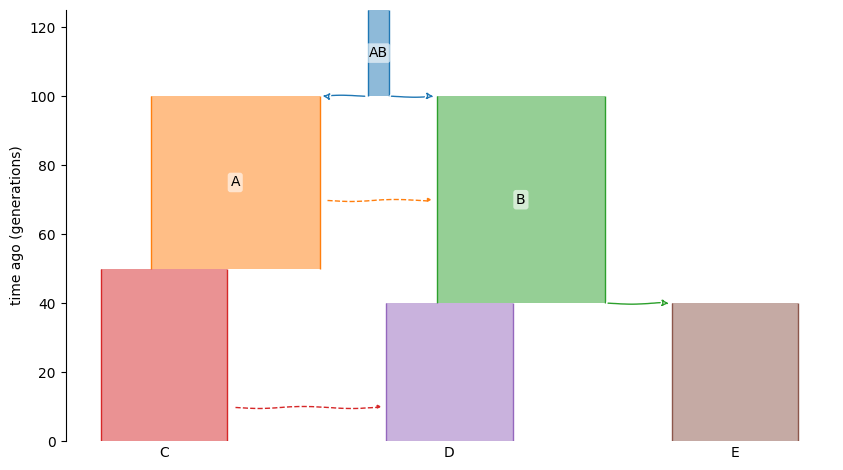

In [8]:
demesdraw.tubes(g)

In [9]:
params1 = momi._default_params
esfs_i_1 = momi.sfs_entry({"A": 0, "B": 0, "C":2, "D":1, "E": 0}, params1)

# Normalize them total expected site frequency (or total branch length)
tbs1 = momi.total_branch_length(params1)
print(f"We expect to see C: 2 and D: 1 type of mutation in {100 * esfs_i_1 / tbs1:.5f}% of all sites when pi_1 = 0.2")

We expect to see C: 2 and D: 1 type of mutation in 0.06826% of all sites when pi_1 = 0.2


In [10]:
params2 = params1.copy()
params2['pi_1'] = 0.
esfs_i_2 = momi.sfs_entry({"A": 0, "B": 0, "C":2, "D":1, "E": 0}, params2)
tbs2 = momi.total_branch_length(params2)
print(f"We expect to see C: 2 and D: 1 type of mutation in {100 * esfs_i_2 / tbs2:.5f}% of all sites when pi_1 = 0.")

We expect to see C: 2 and D: 1 type of mutation in 0.00010% of all sites when pi_1 = 0.
